# Galactic Star-Forming Regions on a Hybrid Mollweide Map

This notebook draws an all-sky Galactic Mollweide dust map with rectangular zoom panels for crowded star-forming regions and reviewed MALCA dippers, LTVs, and microlensing candidates. The star-forming-region table lives in `malca/data/star_forming_regions.csv`; generated figures are written under `output/notebooks/star_forming_regions/`.

Colored outlines indicate distance-resolved molecular-cloud footprints, not complete stellar-membership boundaries. Reviewed candidates are counted as SFR-associated only when they fall inside a retained footprint and have a Gaia distance interval overlapping the adopted cloud slab.


## Setup

Run this notebook in the `malca` conda environment. It uses `numpy`, `pandas`, `matplotlib`, `scipy`, `astropy`, `dustmaps`, and `dustmaps3d`.


In [1]:
from pathlib import Path
import sqlite3
import warnings

warnings.filterwarnings("ignore", message="Configuration file not found", module="dustmaps.config")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import LogNorm
from scipy.ndimage import binary_dilation
from scipy.ndimage import generate_binary_structure
from scipy.ndimage import label as label_connected_components
from astropy.coordinates import SkyCoord
from astropy.table import Table
import astropy.units as u
from dustmaps.sfd import SFDQuery
from dustmaps3d import dustmaps3d
from IPython.display import display

from malca.io.lightcurve_io import load_lightcurve_df
from malca.io.notebook_paths import find_repo_root

REPO_ROOT = find_repo_root()
REGION_CSV = REPO_ROOT / "malca" / "data" / "star_forming_regions.csv"
DUSTMAPS_DIR = REPO_ROOT / "data" / "dustmaps"
SFD_DIR = DUSTMAPS_DIR / "sfd"
OUTPUT_DIR = REPO_ROOT / "output" / "notebooks" / "star_forming_regions"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MALCA_REVIEW_DB = REPO_ROOT / "output" / "runs" / "dat3-full-extended_2026-07-01-v4" / "review" / "review.db"

SHOW_DUST_BACKGROUND = True
DOWNLOAD_SFD_IF_MISSING = False
SHOW_MALCA_REVIEW_CANDIDATES = True
DUST_GRID_N_L = 2880
DUST_GRID_N_B = 1440

TWO_COLUMN_WIDTH_IN = 7.16
TWO_COLUMN_HEIGHT_IN = 5.35
MAP_AXES_RECT = [0.155, 0.425, 0.705, 0.525]
ORION_ZOOM_RECT = [0.500, 0.160, 0.285, 0.255]
INNER_GALAXY_ZOOM_RECT = [0.155, 0.160, 0.285, 0.255]
COLORBAR_AXES_RECT = [0.155, 0.942, 0.705, 0.024]
DIPPER_SFR_COLUMN_RECT = [0.006, 0.135, 0.096, 0.815]
DIPPER_NON_SFR_COLUMN_RECT = [0.898, 0.135, 0.096, 0.815]
LEGEND_ANCHOR = (0.50, 0.012)

BASE_FONT_SIZE_PT = 8.0
AXIS_LABEL_FONT_SIZE_PT = 8.0
TICK_FONT_SIZE_PT = 7.0
REGION_LABEL_FONT_SIZE_PT = 5.0
LEGEND_FONT_SIZE_PT = 6.0
DIPPER_COLUMN_TITLE_FONT_SIZE_PT = 5.6
COLORBAR_FONT_SIZE_PT = 7.0
SFR_LABEL_FONT_WEIGHT = "bold"
BLACK_LABEL_FONT_WEIGHT = "normal"
TICK_HALO = [pe.withStroke(linewidth=1.1, foreground="black")]
LABEL_HALO = [pe.withStroke(linewidth=1.15, foreground="white")]
SFR_TEXT_OUTLINE = [pe.withStroke(linewidth=0.6, foreground="black")]
CANDIDATE_INSIDE_MARKER_COLOR = "#f2c230"
CANDIDATE_OUTSIDE_MARKER_COLOR = "#56b4e9"
DIPPER_INSIDE_MARKER_COLOR = CANDIDATE_INSIDE_MARKER_COLOR
DIPPER_OUTSIDE_MARKER_COLOR = CANDIDATE_OUTSIDE_MARKER_COLOR
CANDIDATE_MAIN_MARKER_SIZE = 12
CANDIDATE_ZOOM_MARKER_SIZE = 18
CANDIDATE_LEGEND_MARKER_SIZE = 4.2
CANDIDATE_MARKER_ZORDER = 30
DIPPER_MARKER_ZORDER = CANDIDATE_MARKER_ZORDER
REVIEWED_CANDIDATE_CLASSES = ("dipper", "ltv", "microlensing")
REVIEWED_CANDIDATE_CLASS_STYLES = {
    "dipper": {"label": "Dippers", "marker": "v", "size_scale": 0.82},
    "ltv": {"label": "LTVs", "marker": "o", "size_scale": 0.70},
    "microlensing": {"label": "Microlenses", "marker": "^", "size_scale": 0.78},
}
DIPPER_LIGHTCURVE_N_PER_GROUP = 20
DUST_SLAB_EBV_THRESHOLD = 0.20
DUST_FOOTPRINT_GRID_STEP_DEG = 0.125
DUST_FOOTPRINT_MARGIN_DEG = 2.0
DUST_FOOTPRINT_MIN_PIXELS = 8


def sfr_text_path_effects(color):
    return [
        pe.withStroke(linewidth=0.6, foreground="black"),
        pe.withStroke(linewidth=0.32, foreground=color),
        pe.Normal(),
    ]


def perceptual_gray_cmap(name="dust_perceptual_gray", lstar_min=0.0, lstar_max=100.0):
    """Neutral grayscale with roughly uniform steps in CIE L* lightness."""
    lstar = np.linspace(lstar_max, lstar_min, 256)
    y = np.where(lstar > 8.0, ((lstar + 16.0) / 116.0) ** 3, lstar / 903.3)
    srgb = np.where(y <= 0.0031308, 12.92 * y, 1.055 * np.power(y, 1.0 / 2.4) - 0.055)
    srgb = np.clip(srgb, 0.0, 1.0)
    colors = np.column_stack([srgb, srgb, srgb, np.ones_like(srgb)])
    return LinearSegmentedColormap.from_list(name, colors)


DUST_CMAP = perceptual_gray_cmap()

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "font.size": BASE_FONT_SIZE_PT,
    "font.family": "serif",
    "font.serif": ["cmr10", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.formatter.use_mathtext": True,
    "axes.unicode_minus": False,
})


## Load Editable Region Masks

In [2]:
REQUIRED_REGION_COLUMNS = [
    "name",
    "l_deg",
    "b_deg",
    "radius_deg",
    "group",
    "distance_pc",
    "distance_min_pc",
    "distance_max_pc",
    "distance_interval_source",
    "distance_interval_notes",
    "notes",
    "source",
]

regions = pd.read_csv(REGION_CSV)
missing = [col for col in REQUIRED_REGION_COLUMNS if col not in regions.columns]
if missing:
    raise ValueError(f"Missing required columns in {REGION_CSV}: {missing}")

regions = regions.copy()
for col in ["l_deg", "b_deg", "radius_deg", "distance_pc", "distance_min_pc", "distance_max_pc"]:
    regions[col] = pd.to_numeric(regions[col], errors="raise")

bad_intervals = regions[
    ~(
        np.isfinite(regions["distance_min_pc"])
        & np.isfinite(regions["distance_max_pc"])
        & (regions["distance_max_pc"] > regions["distance_min_pc"])
    )
]
if not bad_intervals.empty:
    names = ", ".join(bad_intervals["name"].astype(str))
    raise ValueError(f"Invalid sourced distance slab intervals for: {names}")

for source_col in ["distance_interval_source", "distance_interval_notes"]:
    missing_source = regions[source_col].fillna("").astype(str).str.strip().eq("")
    if missing_source.any():
        names = ", ".join(regions.loc[missing_source, "name"].astype(str))
        raise ValueError(f"Missing {source_col} entries for: {names}")

display(regions)


,name,l_deg,b_deg,radius_deg,group,distance_pc,distance_min_pc,distance_max_pc,distance_interval_source,distance_interval_notes,notes,source
0,Taurus,170.0,-15.0,12.0,Nearby clouds,140,120,185,Zucker2019 cloud and sightline distances,Average 141 pc and Taurus sightlines 129-170 p...,Broad Taurus-Auriga visual footprint,Legacy editable seed window for footprint sele...
1,Perseus,160.0,-20.0,8.0,Nearby clouds,300,220,380,Zucker2019 cloud and sightline distances,Average 294 pc and Perseus sightlines 234-347 ...,Broad Perseus molecular cloud footprint,Legacy editable seed window for footprint sele...
2,Orion A,210.0,-19.0,6.0,Orion complex,400,390,480,Zucker2019 cloud and sightline distances,Average 432 pc with Orion sightlines and liter...,Broad Orion A footprint,Legacy editable seed window for footprint sele...
3,Orion B,205.0,-14.0,5.0,Orion complex,400,380,460,Zucker2019 cloud and sightline distances,Average 423 pc with about 21 pc systematic unc...,Broad Orion B footprint,Legacy editable seed window for footprint sele...
4,lambda Orionis,195.0,-12.0,6.0,Orion complex,400,370,455,Zucker2019 cloud and sightline distances,Orion Lam average 402 pc and sightlines 393-42...,Broad lambda Orionis ring footprint,Legacy editable seed window for footprint sele...
5,Mon R2,214.0,-12.0,4.0,Orion-Monoceros,830,725,990,Zucker2019 cloud and sightline distances,Mon R2 sightlines span 767-943 pc with quoted ...,Broad Mon R2 footprint,Legacy editable seed window for footprint sele...
6,Rosette,207.0,-2.0,4.5,Orion-Monoceros,1500,1190,1490,Zucker2019 and Zucker2020 cloud distances,Rosette sightlines span 1261-1413 pc with quot...,Broad Rosette molecular cloud footprint,Legacy editable seed window for footprint sele...
7,Ophiuchus,353.0,16.0,7.0,Nearby clouds,140,100,180,Zucker2020 cloud distances,Ophiuchus components span 109-167 pc with quot...,Broad rho Ophiuchi and L1688/L1689 footprint,Legacy editable seed window for footprint sele...
8,Lupus,338.0,15.0,8.0,Nearby clouds,160,90,305,Zucker2020 cloud distances,Lupus sightlines span 108-239 pc with large co...,Broad Lupus cloud complex footprint,Legacy editable seed window for footprint sele...
9,Chamaeleon,300.0,-16.0,8.0,Nearby clouds,190,140,240,Zucker2020 cloud distances,Chamaeleon sightlines span 161-210 pc with quo...,Broad Chamaeleon complex footprint,Legacy editable seed window for footprint sele...


## Coordinate and Region Geometry Helpers

The plotting helpers wrap Galactic longitude onto `[-180, 180]` degrees. The all-sky panel projects those coordinates onto a Mollweide map centered on `\ell=0`; the zoom panels keep rectangular `\ell,b` axes for local readability.

In [3]:
def wrap_longitude_deg(l_deg):
    """Wrap Galactic longitude to [-180, 180] for plotting."""
    return ((np.asarray(l_deg, dtype=float) + 180.0) % 360.0) - 180.0


def angular_delta_deg(l_deg, center_l_deg):
    """Signed shortest longitude offset from a Galactic center in degrees."""
    return ((np.asarray(l_deg, dtype=float) - float(center_l_deg) + 180.0) % 360.0) - 180.0


def longitude_relative_to_center(l_deg, center_l_deg):
    center_x = float(wrap_longitude_deg(center_l_deg))
    return center_x + angular_delta_deg(l_deg, center_l_deg)


def region_center_coords(region_frame):
    return SkyCoord(
        l=region_frame["l_deg"].to_numpy() * u.deg,
        b=region_frame["b_deg"].to_numpy() * u.deg,
        frame="galactic",
    )


def expected_sfd_files(map_dir=SFD_DIR):
    return [map_dir / "SFD_dust_4096_ngp.fits", map_dir / "SFD_dust_4096_sgp.fits"]


def sfd_files_present(map_dir=SFD_DIR):
    return all(path.exists() for path in expected_sfd_files(map_dir))


def fetch_sfd_to_project_cache(map_dir=SFD_DIR):
    """Fetch SFD FITS files into this project without writing ~/.dustmapsrc."""
    from dustmaps import fetch_utils

    map_dir.mkdir(parents=True, exist_ok=True)
    doi = "10.7910/DVN/EWCNL5"
    for pole in ["ngp", "sgp"]:
        filename = f"SFD_dust_4096_{pole}.fits"
        local_path = map_dir / filename
        if local_path.exists():
            continue
        print(f"Downloading {filename} to {local_path}")
        fetch_utils.dataverse_download_doi(
            doi,
            str(local_path),
            file_requirements={"filename": filename},
        )


def load_sfd_query(map_dir=SFD_DIR):
    if not sfd_files_present(map_dir):
        if DOWNLOAD_SFD_IF_MISSING:
            fetch_sfd_to_project_cache(map_dir)
        else:
            expected = "\n".join(str(path) for path in expected_sfd_files(map_dir))
            raise FileNotFoundError(
                "SFD dust files are missing. Set DOWNLOAD_SFD_IF_MISSING = True "
                "and rerun this cell once, or place the files here:\n"
                f"{expected}"
            )
    return SFDQuery(map_dir=str(map_dir))


def make_sfd_lonlat_grid(n_l=DUST_GRID_N_L, n_b=DUST_GRID_N_B):
    """Sample SFD E(B-V) on a regular Galactic longitude/latitude grid."""
    sfd = load_sfd_query()
    x_edges = np.linspace(-180.0, 180.0, n_l + 1)
    y_edges = np.linspace(-90.0, 90.0, n_b + 1)
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
    xx, yy = np.meshgrid(x_centers, y_centers)
    l_deg = xx % 360.0
    b_deg = yy
    coords = SkyCoord(l=l_deg.ravel() * u.deg, b=b_deg.ravel() * u.deg, frame="galactic")
    ebv = sfd.query(coords).reshape(n_b, n_l)
    return x_edges, y_edges, ebv


def build_dust_grid():
    if not SHOW_DUST_BACKGROUND:
        return None
    return make_sfd_lonlat_grid()


def local_lonlat_grid(region, grid_step=DUST_FOOTPRINT_GRID_STEP_DEG):
    half_width = float(region["radius_deg"]) + DUST_FOOTPRINT_MARGIN_DEG
    center_x = float(wrap_longitude_deg(region["l_deg"]))
    center_b = float(region["b_deg"])
    x_values = np.arange(center_x - half_width, center_x + half_width + 0.5 * grid_step, grid_step)
    y_min = max(-89.5, center_b - half_width)
    y_max = min(89.5, center_b + half_width)
    y_values = np.arange(y_min, y_max + 0.5 * grid_step, grid_step)
    x_grid, b_grid = np.meshgrid(x_values, y_values)
    l_grid = x_grid % 360.0
    return x_grid, l_grid, b_grid


def _dustmaps3d_ebv(l_grid, b_grid, distance_pc):
    l_flat = np.asarray(l_grid, dtype=float).ravel()
    b_flat = np.asarray(b_grid, dtype=float).ravel()
    distance_kpc = np.full(l_flat.size, float(distance_pc) / 1000.0, dtype=float)
    ebv, *_ = dustmaps3d(l_flat, b_flat, distance_kpc)
    return np.asarray(ebv, dtype=float).reshape(np.shape(l_grid))


def query_dust_slab_delta(region):
    x_grid, l_grid, b_grid = local_lonlat_grid(region)
    ebv_near = _dustmaps3d_ebv(l_grid, b_grid, region["distance_min_pc"])
    ebv_far = _dustmaps3d_ebv(l_grid, b_grid, region["distance_max_pc"])
    delta_ebv = np.maximum(ebv_far - ebv_near, 0.0)
    delta_ebv[~np.isfinite(delta_ebv)] = np.nan
    return x_grid, l_grid, b_grid, delta_ebv


def _seed_circle_mask(x_grid, b_grid, region):
    center_x = float(wrap_longitude_deg(region["l_deg"]))
    center_b = float(region["b_deg"])
    cos_b = np.cos(np.deg2rad(center_b))
    dx = (np.asarray(x_grid, dtype=float) - center_x) * cos_b
    dy = np.asarray(b_grid, dtype=float) - center_b
    return (dx * dx + dy * dy) <= float(region["radius_deg"]) ** 2


def _grid_indices_for_points(x_grid, b_grid, x_values, b_values):
    x_axis = np.asarray(x_grid[0, :], dtype=float)
    b_axis = np.asarray(b_grid[:, 0], dtype=float)
    dx = float(np.nanmedian(np.diff(x_axis)))
    db = float(np.nanmedian(np.diff(b_axis)))
    if not np.isfinite(dx) or not np.isfinite(db) or dx == 0.0 or db == 0.0:
        return np.array([], dtype=int), np.array([], dtype=int), np.array([], dtype=bool)
    cols = np.rint((np.asarray(x_values, dtype=float) - x_axis[0]) / dx).astype(int)
    rows = np.rint((np.asarray(b_values, dtype=float) - b_axis[0]) / db).astype(int)
    valid = (rows >= 0) & (rows < len(b_axis)) & (cols >= 0) & (cols < len(x_axis))
    return rows, cols, valid


def _contour_segments_from_delta(x_grid, b_grid, delta_ebv, retained_mask):
    if int(np.count_nonzero(retained_mask)) < DUST_FOOTPRINT_MIN_PIXELS:
        return []
    filter_mask = binary_dilation(
        retained_mask,
        structure=generate_binary_structure(2, 2),
        iterations=1,
    )
    fig_tmp, ax_tmp = plt.subplots(figsize=(1.0, 1.0))
    try:
        contour_set = ax_tmp.contour(x_grid, b_grid, delta_ebv, levels=[DUST_SLAB_EBV_THRESHOLD])
        segments = []
        for segment in contour_set.allsegs[0]:
            segment = np.asarray(segment, dtype=float)
            if len(segment) < 3:
                continue
            rows, cols, valid = _grid_indices_for_points(x_grid, b_grid, segment[:, 0], segment[:, 1])
            if np.any(valid):
                touches_retained_component = np.any(filter_mask[rows[valid], cols[valid]])
            else:
                touches_retained_component = False
            if touches_retained_component:
                segments.append(segment.copy())
    finally:
        plt.close(fig_tmp)
    return segments


def build_region_dust_footprints(regions):
    footprints = {}
    diagnostics = []
    connectivity = generate_binary_structure(2, 2)

    for _, region in regions.iterrows():
        region_name = str(region["name"])
        x_grid, l_grid, b_grid, delta_ebv = query_dust_slab_delta(region)
        threshold_mask = np.isfinite(delta_ebv) & (delta_ebv >= DUST_SLAB_EBV_THRESHOLD)
        labels, n_components_total = label_connected_components(threshold_mask, structure=connectivity)
        seed_mask = _seed_circle_mask(x_grid, b_grid, region)
        retained_labels = sorted(set(labels[threshold_mask & seed_mask].ravel()) - {0})

        retained_mask = np.zeros_like(threshold_mask, dtype=bool)
        retained_components = 0
        for label_id in retained_labels:
            component_mask = labels == label_id
            if int(np.count_nonzero(component_mask)) < DUST_FOOTPRINT_MIN_PIXELS:
                continue
            retained_mask |= component_mask
            retained_components += 1

        segments = _contour_segments_from_delta(x_grid, b_grid, delta_ebv, retained_mask)
        max_delta = float(np.nanmax(delta_ebv)) if np.isfinite(delta_ebv).any() else np.nan
        retained_pixels = int(np.count_nonzero(retained_mask))
        status = "ok" if segments else ("no_threshold_pixels" if not np.any(threshold_mask) else "no_retained_contours")

        footprints[region_name] = {
            "region": region.to_dict(),
            "x_grid": x_grid,
            "l_grid": l_grid,
            "b_grid": b_grid,
            "delta_ebv": delta_ebv,
            "retained_mask": retained_mask,
            "segments": segments,
            "max_delta_ebv": max_delta,
            "n_components_total": int(n_components_total),
            "n_retained_components": int(retained_components),
            "n_contours": int(len(segments)),
            "retained_pixels": retained_pixels,
            "status": status,
        }
        diagnostics.append(
            {
                "name": region_name,
                "distance_min_pc": float(region["distance_min_pc"]),
                "distance_max_pc": float(region["distance_max_pc"]),
                "distance_interval_source": str(region["distance_interval_source"]),
                "max_delta_ebv": max_delta,
                "n_components_total": int(n_components_total),
                "n_retained_components": int(retained_components),
                "n_contours": int(len(segments)),
                "retained_pixels": retained_pixels,
                "status": status,
            }
        )

    diagnostics = pd.DataFrame(diagnostics)
    if not any(footprint["segments"] for footprint in footprints.values()):
        raise RuntimeError(
            "No distance-slab dust contours were retained. Check dustmaps3d availability "
            "and DUST_SLAB_EBV_THRESHOLD."
        )
    return footprints, diagnostics


## Optional Star Catalog Overlay

Set `STAR_CATALOG_PATH` to a CSV or FITS file when you have an additional star table. The loader accepts either Galactic `l/b` columns or ICRS `ra/dec` columns. The synthetic demo is off by default so the main figure shows the reviewed MALCA candidates without extra test points.

In [4]:
STAR_CATALOG_PATH = None
USE_SYNTHETIC_TEST_STARS = False


def _find_column(table, candidates):
    normalized = {str(col).lower().replace(" ", "_"): col for col in table.columns}
    for candidate in candidates:
        key = candidate.lower().replace(" ", "_")
        if key in normalized:
            return normalized[key]
    return None


def read_star_table(path):
    path = Path(path)
    suffixes = "".join(path.suffixes).lower()
    if suffixes.endswith(".csv"):
        return pd.read_csv(path)
    if suffixes.endswith((".fits", ".fit", ".fits.gz")):
        return Table.read(path).to_pandas()
    raise ValueError(f"Unsupported star table type: {path}")


def star_coords_from_table(star_table):
    l_col = _find_column(star_table, ["l", "l_deg", "gal_l", "gal_l_deg", "glon", "galactic_l"])
    b_col = _find_column(star_table, ["b", "b_deg", "gal_b", "gal_b_deg", "glat", "galactic_b"])
    if l_col is not None and b_col is not None:
        return SkyCoord(
            l=pd.to_numeric(star_table[l_col]).to_numpy() * u.deg,
            b=pd.to_numeric(star_table[b_col]).to_numpy() * u.deg,
            frame="galactic",
        )

    ra_col = _find_column(star_table, ["ra", "ra_deg", "raj2000", "ra_icrs"])
    dec_col = _find_column(star_table, ["dec", "dec_deg", "dej2000", "dec_icrs"])
    if ra_col is not None and dec_col is not None:
        return SkyCoord(
            ra=pd.to_numeric(star_table[ra_col]).to_numpy() * u.deg,
            dec=pd.to_numeric(star_table[dec_col]).to_numpy() * u.deg,
            frame="icrs",
        ).galactic

    raise ValueError(
        "Star table must contain Galactic l/b columns or ICRS ra/dec columns."
    )


def make_synthetic_star_table():
    return pd.DataFrame(
        {
            "source_id": [
                "demo_taurus_inside",
                "demo_orion_overlap",
                "demo_cygnus_inside",
                "demo_inner_galaxy_inside",
                "demo_outside_masks",
            ],
            "l_deg": [170.5, 207.5, 80.5, 352.5, 250.0],
            "b_deg": [-15.5, -16.5, 1.2, 0.8, 55.0],
            "distance_gspphot": [145.0, 425.0, 1450.0, 1680.0, np.nan],
            "parallax": [np.nan, np.nan, np.nan, np.nan, 1.0],
            "parallax_error": [np.nan, np.nan, np.nan, np.nan, 0.05],
        }
    )


def load_star_table():
    if STAR_CATALOG_PATH is not None:
        return read_star_table(STAR_CATALOG_PATH), "user catalog"
    if USE_SYNTHETIC_TEST_STARS:
        return make_synthetic_star_table(), "synthetic demo"
    return pd.DataFrame(), "no star catalog"


def finite_float(value):
    try:
        if value is None or pd.isna(value):
            return np.nan
        output = float(value)
    except (TypeError, ValueError):
        return np.nan
    return output if np.isfinite(output) else np.nan


def source_distance_interval_pc(row):
    distance_gspphot = finite_float(row.get("distance_gspphot"))
    if distance_gspphot > 0.0:
        return distance_gspphot, distance_gspphot, "distance_gspphot"

    parallax = finite_float(row.get("parallax"))
    parallax_error = finite_float(row.get("parallax_error"))
    if parallax > 0.0 and parallax_error > 0.0 and (parallax - parallax_error) > 0.0:
        d_near = 1000.0 / (parallax + parallax_error)
        d_far = 1000.0 / (parallax - parallax_error)
        return min(d_near, d_far), max(d_near, d_far), "parallax_1sigma"

    return np.nan, np.nan, "none"


def intervals_overlap_pc(candidate_min_pc, candidate_max_pc, region_min_pc, region_max_pc):
    values = [candidate_min_pc, candidate_max_pc, region_min_pc, region_max_pc]
    if not all(np.isfinite(values)):
        return False
    return max(candidate_min_pc, region_min_pc) <= min(candidate_max_pc, region_max_pc)


def point_in_region_footprint(l_deg, b_deg, footprint):
    if not footprint or "retained_mask" not in footprint:
        return False
    region = footprint["region"]
    x = float(longitude_relative_to_center(l_deg, region["l_deg"]))
    y = float(b_deg)
    rows, cols, valid = _grid_indices_for_points(footprint["x_grid"], footprint["b_grid"], [x], [y])
    if len(valid) == 0 or not bool(valid[0]):
        return False
    return bool(footprint["retained_mask"][rows[0], cols[0]])


def assign_region_membership(star_table, regions, footprints):
    if star_table.empty:
        output = star_table.copy()
        for col, default in (
            ("gal_l_deg", np.nan),
            ("gal_b_deg", np.nan),
            ("sfr_footprint_matches", ""),
            ("n_sfr_footprint_matches", 0),
            ("sfr_matches", ""),
            ("n_sfr_matches", 0),
            ("sfr_distance_source", "none"),
            ("sfr_distance_min_pc", np.nan),
            ("sfr_distance_max_pc", np.nan),
            ("nearest_sfr_sep_deg", np.nan),
        ):
            output[col] = default
        return output

    star_coords = star_coords_from_table(star_table)
    sfr_coords = region_center_coords(regions)

    footprint_memberships = []
    distance_memberships = []
    distance_sources = []
    distance_min_values = []
    distance_max_values = []
    min_sep_deg = []

    for row_idx, star in zip(star_table.index, star_coords):
        row = star_table.loc[row_idx]
        candidate_min_pc, candidate_max_pc, distance_source = source_distance_interval_pc(row)

        footprint_hits = []
        distance_hits = []
        for _, region in regions.iterrows():
            region_name = str(region["name"])
            if not point_in_region_footprint(star.l.deg, star.b.deg, footprints.get(region_name)):
                continue
            footprint_hits.append(region_name)
            if intervals_overlap_pc(
                candidate_min_pc,
                candidate_max_pc,
                float(region["distance_min_pc"]),
                float(region["distance_max_pc"]),
            ):
                distance_hits.append(region_name)

        footprint_memberships.append(";".join(footprint_hits))
        distance_memberships.append(";".join(distance_hits))
        distance_sources.append(distance_source)
        distance_min_values.append(candidate_min_pc)
        distance_max_values.append(candidate_max_pc)
        min_sep_deg.append(float(np.min(star.separation(sfr_coords).deg)))

    output = star_table.copy()
    output["gal_l_deg"] = star_coords.l.deg
    output["gal_b_deg"] = star_coords.b.deg
    output["sfr_footprint_matches"] = footprint_memberships
    output["n_sfr_footprint_matches"] = [
        0 if match == "" else match.count(";") + 1 for match in footprint_memberships
    ]
    output["sfr_matches"] = distance_memberships
    output["n_sfr_matches"] = [
        0 if match == "" else match.count(";") + 1 for match in distance_memberships
    ]
    output["sfr_distance_source"] = distance_sources
    output["sfr_distance_min_pc"] = distance_min_values
    output["sfr_distance_max_pc"] = distance_max_values
    output["nearest_sfr_sep_deg"] = min_sep_deg
    return output


def sqlite_readonly_uri(path):
    return f"file:{Path(path).resolve().as_posix()}?mode=ro&immutable=1"


def load_malca_review_candidates(review_db=MALCA_REVIEW_DB):
    if not SHOW_MALCA_REVIEW_CANDIDATES:
        return pd.DataFrame()
    if not Path(review_db).exists():
        print(f"MALCA review DB not found: {review_db}")
        return pd.DataFrame()

    query = """
        SELECT
            c.candidate_id,
            c.asas_sn_id,
            c.lc_path,
            c.source_path,
            c.ra,
            c.dec,
            c.gal_l AS gal_l_deg,
            c.gal_b AS gal_b_deg,
            c.distance_gspphot,
            c.parallax,
            c.parallax_error,
            c.dipper_score,
            c.dipper_n_dips,
            c.dipper_n_valid_dips,
            r.event_class,
            r.morphology_primary,
            r.morphology_secondary,
            r.physical_primary,
            r.physical_secondary,
            r.classification_confidence,
            r.status,
            r.updated_at
        FROM reviews AS r
        JOIN candidates AS c USING(candidate_id)
        WHERE r.event_class IN ('dipper', 'ltv', 'microlensing')
          AND c.gal_l IS NOT NULL
          AND c.gal_b IS NOT NULL
        ORDER BY r.event_class, c.gal_l
    """
    with sqlite3.connect(sqlite_readonly_uri(review_db), uri=True) as conn:
        return pd.read_sql_query(query, conn)


region_footprints, footprint_diagnostics = build_region_dust_footprints(regions)
display(footprint_diagnostics)

stars_raw, star_source = load_star_table()
stars_with_membership = assign_region_membership(stars_raw, regions, region_footprints)
malca_review_candidates = load_malca_review_candidates()
malca_review_candidates_with_membership = assign_region_membership(
    malca_review_candidates,
    regions,
    region_footprints,
)
print(f"Star source: {star_source}")
display(stars_with_membership)
print(f"Reviewed MALCA dippers/LTVs/microlenses loaded: {len(malca_review_candidates_with_membership)}")
if not malca_review_candidates_with_membership.empty:
    footprint_only = malca_review_candidates_with_membership["n_sfr_footprint_matches"].fillna(0) > 0
    distance_consistent = malca_review_candidates_with_membership["n_sfr_matches"].fillna(0) > 0
    print(f"Footprint-only reviewed candidate count: {int(footprint_only.sum())}")
    print(f"Distance-consistent SFR reviewed candidate count: {int(distance_consistent.sum())}")
    class_membership_summary = (
        malca_review_candidates_with_membership.assign(
            sfr_group=np.where(distance_consistent, "SFR", "non-SFR")
        )
        .groupby(["event_class", "sfr_group"], dropna=False)
        .size()
        .unstack(fill_value=0)
    )
    class_order = [
        event_class
        for event_class in REVIEWED_CANDIDATE_CLASSES
        if event_class in class_membership_summary.index
    ]
    display(class_membership_summary.reindex(class_order))
display(malca_review_candidates_with_membership.head(10))


,name,distance_min_pc,distance_max_pc,distance_interval_source,max_delta_ebv,n_components_total,n_retained_components,n_contours,retained_pixels,status
0,Taurus,120.0,185.0,Zucker2019 cloud and sightline distances,0.921117,854,95,746,10439,ok
1,Perseus,220.0,380.0,Zucker2019 cloud and sightline distances,0.788816,399,32,207,4032,ok
2,Orion A,390.0,480.0,Zucker2019 cloud and sightline distances,1.150892,82,5,89,3114,ok
3,Orion B,380.0,460.0,Zucker2019 cloud and sightline distances,1.162895,110,5,138,3260,ok
4,lambda Orionis,370.0,455.0,Zucker2019 cloud and sightline distances,0.822412,184,13,163,2197,ok
5,Mon R2,725.0,990.0,Zucker2019 cloud and sightline distances,0.728653,68,2,105,2452,ok
6,Rosette,1190.0,1490.0,Zucker2019 and Zucker2020 cloud distances,0.775604,89,11,42,639,ok
7,Ophiuchus,100.0,180.0,Zucker2020 cloud distances,0.694347,381,18,201,3385,ok
8,Lupus,90.0,305.0,Zucker2020 cloud distances,0.809300,133,7,425,6445,ok
9,Chamaeleon,140.0,240.0,Zucker2020 cloud distances,0.683534,227,21,281,2738,ok


Star source: no star catalog


,gal_l_deg,gal_b_deg,sfr_footprint_matches,n_sfr_footprint_matches,sfr_matches,n_sfr_matches,sfr_distance_source,sfr_distance_min_pc,sfr_distance_max_pc,nearest_sfr_sep_deg


Reviewed MALCA dippers/LTVs/microlenses loaded: 136
Footprint-only reviewed candidate count: 13
Distance-consistent SFR reviewed candidate count: 6


sfr_group,SFR,non-SFR
event_class,,
dipper,5,66
ltv,1,43
microlensing,0,21


,candidate_id,asas_sn_id,lc_path,source_path,ra,dec,gal_l_deg,gal_b_deg,distance_gspphot,parallax,...,status,updated_at,sfr_footprint_matches,n_sfr_footprint_matches,sfr_matches,n_sfr_matches,sfr_distance_source,sfr_distance_min_pc,sfr_distance_max_pc,nearest_sfr_sep_deg
0,stv_395138016907,395138016907,/Users/calder/code/malca/output/runs/dat3-full...,/Users/calder/code/malca/output/runs/dat3-full...,277.741981,-32.967748,1.116499,-10.458810,1795.319702,0.589301,...,reviewed,2026-07-09T22:01:30.595480+00:00,,0,,0,distance_gspphot,1795.319702,1795.319702,7.618318
1,stv_523986354332,523986354332,/Users/calder/code/malca/output/runs/dat3-full...,/Users/calder/code/malca/output/runs/dat3-full...,277.018398,-26.937393,6.309374,-7.228205,1048.230469,0.909955,...,reviewed,2026-03-20T19:59:19.205763+00:00,,0,,0,distance_gspphot,1048.230469,1048.230469,6.266145
2,stv_369367489518,369367489518,/Users/calder/code/malca/output/runs/dat3-full...,/Users/calder/code/malca/output/runs/dat3-full...,273.812473,-20.528809,10.635086,-1.652918,NaN,0.721907,...,reviewed,2026-03-20T05:25:02.843857+00:00,Eagle-Omega,1,Eagle-Omega,1,parallax_1sigma,1346.457566,1426.279322,3.692279
3,stv_489626538045,489626538045,/Users/calder/code/malca/output/runs/dat3-full...,/Users/calder/code/malca/output/runs/dat3-full...,276.585567,-19.645957,12.639530,-3.537811,NaN,0.486532,...,reviewed,2026-07-09T05:26:40.047315+00:00,Eagle-Omega,1,,0,parallax_1sigma,1984.323264,2131.682045,5.612987
4,stv_180388640882,180388640882,/Users/calder/code/malca/output/runs/dat3-full...,/Users/calder/code/malca/output/runs/dat3-full...,254.926717,15.960965,35.585360,31.750225,111.488899,8.817785,...,reviewed,2026-07-09T18:31:58.416764+00:00,,0,,0,distance_gspphot,111.488899,111.488899,27.257734
5,stv_283467842509,283467842509,/Users/calder/code/malca/output/runs/dat3-full...,/Users/calder/code/malca/output/runs/dat3-full...,286.793964,3.489529,37.833650,-1.902571,3207.702637,0.341922,...,reviewed,2026-07-09T05:01:48.327911+00:00,,0,,0,distance_gspphot,3207.702637,3207.702637,10.435147
6,stv_240519504803,240519504803,/Users/calder/code/malca/output/runs/dat3-full...,/Users/calder/code/malca/output/runs/dat3-full...,291.423012,3.696192,40.158803,-5.903510,NaN,0.541862,...,reviewed,2026-07-09T04:10:55.767742+00:00,,0,,0,parallax_1sigma,1790.584136,1903.863836,14.891928
7,stv_163209590869,163209590869,/Users/calder/code/malca/output/runs/dat3-full...,/Users/calder/code/malca/output/runs/dat3-full...,285.814682,22.296979,54.187040,7.501425,NaN,0.250797,...,reviewed,2026-06-25T07:37:43.165461+00:00,,0,,0,parallax_1sigma,3802.538217,4190.917559,24.168903
8,stv_197569226514,197569226514,/Users/calder/code/malca/output/runs/dat3-full...,/Users/calder/code/malca/output/runs/dat3-full...,296.298507,19.233931,56.113441,-2.584001,5115.370605,0.163251,...,reviewed,2026-07-12T01:20:02.071185+00:00,,0,,0,distance_gspphot,5115.370605,5115.370605,24.147784
9,stv_240518636016,240518636016,/Users/calder/code/malca/output/runs/dat3-full...,/Users/calder/code/malca/output/runs/dat3-full...,290.972718,23.565928,57.498225,3.851770,510.069000,1.812412,...,reviewed,2026-06-10T18:48:29.416974+00:00,,0,,0,distance_gspphot,510.069000,510.069000,22.659178


## Draw the Map

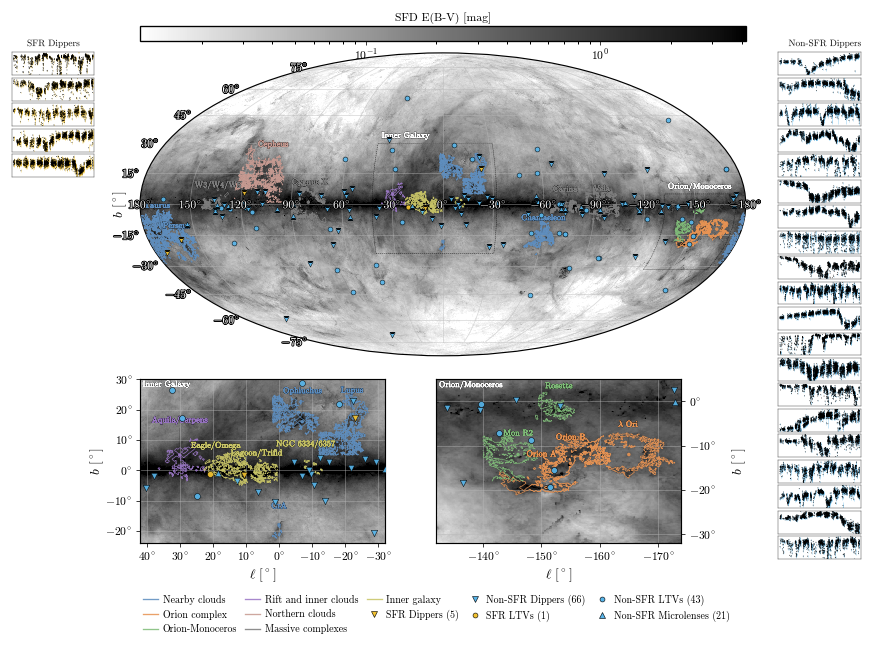

Saved /Users/calder/code/malca/output/notebooks/star_forming_regions/star_forming_regions_mollweide_dust_zoom.pdf
Colored outlines indicate distance-resolved molecular-cloud footprints defined by Delta E(B-V) >= 0.20 mag within sourced heliocentric distance intervals.


In [5]:
def wrap_longitude_deg(l_deg):
    """Wrap Galactic longitude to [-180, 180] for plotting."""
    return ((np.asarray(l_deg, dtype=float) + 180.0) % 360.0) - 180.0


def galactic_to_rectangular(l_deg, b_deg):
    return wrap_longitude_deg(l_deg), np.asarray(b_deg, dtype=float)


def galactic_to_mollweide(l_deg, b_deg):
    l_wrapped = wrap_longitude_deg(l_deg)
    return -np.deg2rad(l_wrapped), np.deg2rad(np.asarray(b_deg, dtype=float))


def split_wrapped_longitude_segments(x, y, max_jump):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    split_at = np.where(np.abs(np.diff(x)) > max_jump)[0] + 1
    return zip(np.split(x, split_at), np.split(y, split_at))


def longitude_tick_label(x_value):
    label = int(round(x_value))
    return rf"${label}^{{\circ}}$"


def ticks_for_xlim(xlim, step):
    left, right = xlim
    lo = min(left, right)
    hi = max(left, right)
    ticks = np.arange(np.floor(lo / step) * step, np.ceil(hi / step) * step + 0.5 * step, step)
    ticks = ticks[(ticks >= lo - 1e-9) & (ticks <= hi + 1e-9)]
    return ticks[::-1] if left > right else ticks


def configure_mollweide_galactic_axis(ax):
    tick_labels = np.arange(180, -181, -30)
    ax.set_xticks(-np.deg2rad(tick_labels))
    ax.set_xticklabels(["" for _ in tick_labels])

    y_ticks = np.arange(-75, 76, 15)
    ax.set_yticks(np.deg2rad(y_ticks))
    ax.set_yticklabels(["" for _ in y_ticks])

    ax.grid(color="0.72", linewidth=0.45, alpha=0.55)
    ax.set_xlabel("")
    ax.set_ylabel(r"$b$ [$^\circ$]", fontsize=AXIS_LABEL_FONT_SIZE_PT, labelpad=2)
    ax.tick_params(axis="both", labelsize=TICK_FONT_SIZE_PT, length=2.6, width=0.45, pad=2)

    for value in tick_labels:
        ax.annotate(
            longitude_tick_label(value),
            xy=(-np.deg2rad(value), 0.0),
            xytext=(0, 0),
            textcoords="offset points",
            ha="center",
            va="center",
            fontsize=TICK_FONT_SIZE_PT,
            color="white",
            path_effects=TICK_HALO,
            annotation_clip=False,
            zorder=40,
        )
    for value in y_ticks:
        if value == 0:
            continue
        ax.annotate(
            rf"${int(value)}^{{\circ}}$",
            xy=(-np.pi, np.deg2rad(value)),
            xytext=(-4, 0),
            textcoords="offset points",
            ha="right",
            va="center",
            fontsize=TICK_FONT_SIZE_PT,
            color="white",
            path_effects=TICK_HALO,
            annotation_clip=False,
            zorder=20,
        )
    for spine in ax.spines.values():
        spine.set_linewidth(0.7)


def configure_rectangular_galactic_axis(
    ax,
    xlim=(180.0, -180.0),
    ylim=(-90.0, 90.0),
    l_step=30.0,
    b_step=15.0,
    show_xlabel=True,
    show_ylabel=True,
    show_y_ticklabels=True,
    y_tick_side="left",
    y_label_coords=None,
):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xticks(ticks_for_xlim(xlim, l_step))
    ax.set_xticklabels([longitude_tick_label(value) for value in ax.get_xticks()])
    y_ticks = np.arange(
        np.ceil(ylim[0] / b_step) * b_step,
        np.floor(ylim[1] / b_step) * b_step + 0.5 * b_step,
        b_step,
    )
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([rf"${int(value)}^{{\circ}}$" for value in y_ticks])
    ax.tick_params(axis="both", labelsize=TICK_FONT_SIZE_PT, length=2.6, width=0.45, pad=2)
    ax.grid(color="0.72", linewidth=0.45, alpha=0.55)
    if show_xlabel:
        ax.set_xlabel(r"$\ell$ [$^\circ$]", fontsize=AXIS_LABEL_FONT_SIZE_PT, labelpad=2)
    else:
        ax.set_xlabel("")
    if show_ylabel:
        ax.set_ylabel(r"$b$ [$^\circ$]", fontsize=AXIS_LABEL_FONT_SIZE_PT, labelpad=2)
        if y_label_coords is not None:
            ax.yaxis.set_label_coords(*y_label_coords)
    else:
        ax.set_ylabel("")
    if show_y_ticklabels and y_tick_side == "right":
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")
        ax.tick_params(axis="y", labelleft=False, labelright=True)
    elif show_y_ticklabels:
        ax.yaxis.tick_left()
        ax.yaxis.set_label_position("left")
        ax.tick_params(axis="y", labelleft=True, labelright=False)
    else:
        ax.tick_params(axis="y", labelleft=False, labelright=False)
    for spine in ax.spines.values():
        spine.set_linewidth(0.7)


REGION_DISPLAY_NAMES = {
    "lambda Orionis": r"$\lambda$ Ori",
    "Aquila-Serpens": "Aquila/Serpens",
    "Lagoon-Trifid": "Lagoon/Trifid",
    "Eagle-Omega": "Eagle/Omega",
    "W3-W4-W5": "W3/W4/W5",
    "Corona Australis": "CrA",
    "NGC 6334-6357": "NGC 6334/6357",
}

SFR_GROUP_COLORS = {
    "Nearby clouds": "#5f8fc0",
    "Orion complex": "#e89454",
    "Orion-Monoceros": "#81bd7a",
    "Northern clouds": "#c89b92",
    "Rift and inner clouds": "#9b78c6",
    "Massive complexes": "#7f7f7f",
    "Inner galaxy": "#c9c568",
}

MAIN_LABEL_REGIONS = {
    "Taurus",
    "Perseus",
    "Cepheus",
    "Cygnus X",
    "Carina",
    "Vela",
    "Chamaeleon",
    "W3-W4-W5",
}

MAIN_LABEL_PLACEMENTS = {
    "Taurus": (0.00, 1.20),
    "Perseus": (0.00, 1.20),
    "Cepheus": (0.00, 1.20),
    "Cygnus X": (0.00, 1.22),
    "Carina": (0.00, 1.18),
    "Vela": (0.00, 1.18),
    "Chamaeleon": (0.00, 1.18),
    "W3-W4-W5": (0.00, 1.20),
}

ORION_LABEL_PLACEMENTS = {
    "Orion A": (0.00, 1.18),
    "Orion B": (0.00, 1.18),
    "lambda Orionis": (0.00, 1.18),
    "Mon R2": (0.00, 1.20),
    "Rosette": (0.00, 1.22),
}

INNER_LABEL_PLACEMENTS = {
    "Ophiuchus": (0.00, 1.45),
    "Lupus": (0.00, 1.42),
    "Corona Australis": (0.00, 1.55),
    "Aquila-Serpens": (0.00, 1.45),
    "Lagoon-Trifid": (-0.05, 1.50),
    "Eagle-Omega": (0.42, 1.65),
    "NGC 6334-6357": (0.00, 1.55),
}

ORION_ZOOM_XLIM = (-132.0, -174.0)  # l = 228 -> 186 deg, displayed left-to-right.
ORION_ZOOM_YLIM = (-32.0, 5.0)
INNER_GALAXY_ZOOM_XLIM = (42.0, -32.0)  # l = 42 -> 328 deg, crossing l=0.
INNER_GALAXY_ZOOM_YLIM = (-24.0, 30.0)


def dust_norm_from_grid(dust_grid):
    _, _, ebv = dust_grid
    positive = np.asarray(ebv, dtype=float)
    positive = positive[np.isfinite(positive) & (positive > 0.0)]
    if positive.size == 0:
        raise ValueError("Dust grid has no positive finite SFD E(B-V) values to plot.")
    vmin = max(float(np.nanpercentile(positive, 4.0)), 1.0e-3)
    vmax = float(np.nanpercentile(positive, 99.5))
    if vmax <= vmin:
        vmax = vmin * 10.0
    return LogNorm(vmin=vmin, vmax=vmax)


def draw_dust_background(ax, dust_grid, projection="rectangular", norm=None):
    x_edges, y_edges, ebv = dust_grid
    ebv = np.asarray(ebv, dtype=float)
    masked_ebv = np.ma.masked_invalid(np.ma.masked_less_equal(ebv, 0.0))

    if projection == "mollweide":
        x_plot = -np.deg2rad(np.asarray(x_edges)[::-1])
        y_plot = np.deg2rad(y_edges)
        data_plot = masked_ebv[:, ::-1]
    elif projection == "rectangular":
        x_plot = x_edges
        y_plot = y_edges
        data_plot = masked_ebv
    else:
        raise ValueError(f"Unknown projection: {projection}")

    return ax.pcolormesh(
        x_plot,
        y_plot,
        data_plot,
        shading="auto",
        cmap=DUST_CMAP,
        norm=norm if norm is not None else dust_norm_from_grid(dust_grid),
        alpha=1.0,
        zorder=0,
        rasterized=True,
    )


def region_in_view(region, xlim, ylim, margin=2.0):
    x = float(wrap_longitude_deg(region["l_deg"]))
    y = float(region["b_deg"])
    lo_x, hi_x = min(xlim), max(xlim)
    lo_y, hi_y = min(ylim), max(ylim)
    return (lo_x - margin <= x <= hi_x + margin) and (lo_y - margin <= y <= hi_y + margin)


def label_anchor_from_region(region, placements):
    dl_scale, db_scale = placements.get(region["name"], (0.0, 0.0))
    radius = float(region["radius_deg"])
    label_l = float(region["l_deg"]) + dl_scale * radius
    label_b = np.clip(float(region["b_deg"]) + db_scale * radius, -89.0, 89.0)
    return label_l, label_b, float(np.hypot(dl_scale, db_scale))


def projected_coords(l_deg, b_deg, projection):
    if projection == "mollweide":
        return galactic_to_mollweide(l_deg, b_deg)
    if projection == "rectangular":
        return galactic_to_rectangular(l_deg, b_deg)
    raise ValueError(f"Unknown projection: {projection}")


def draw_zoom_footprint_mollweide(ax, xlim, ylim, label):
    x0, x1 = xlim
    y0, y1 = ylim
    n_edge = 120
    bottom_x = np.linspace(x0, x1, n_edge)
    right_y = np.linspace(y0, y1, n_edge)
    top_x = np.linspace(x1, x0, n_edge)
    left_y = np.linspace(y1, y0, n_edge)
    box_x = np.concatenate([bottom_x, np.full(n_edge, x1), top_x, np.full(n_edge, x0)])
    box_y = np.concatenate([np.full(n_edge, y0), right_y, np.full(n_edge, y1), left_y])
    mx, my = galactic_to_mollweide(box_x, box_y)
    for xs, ys in split_wrapped_longitude_segments(mx, my, max_jump=np.pi):
        ax.plot(
            xs,
            ys,
            color="black",
            linewidth=0.24,
            alpha=1.0,
            linestyle=(0, (3.0, 2.0)),
            zorder=6,
        )

    label_x, label_y = galactic_to_mollweide(x0, y1)
    ax.annotate(
        label,
        xy=(label_x, label_y),
        xytext=(2, 2),
        textcoords="offset points",
        ha="left",
        va="bottom",
        fontsize=REGION_LABEL_FONT_SIZE_PT,
        fontweight=SFR_LABEL_FONT_WEIGHT,
        color="white",
        path_effects=sfr_text_path_effects("white"),
        zorder=8,
    )


def draw_region_layers(
    ax,
    regions,
    group_colors,
    footprints=None,
    projection="rectangular",
    label_regions=False,
    label_names=None,
    xlim=None,
    ylim=None,
    label_placements=None,
    clip_labels=False,
):
    if label_placements is None:
        label_placements = {}
    if footprints is None:
        footprints = {}
    max_jump = np.pi if projection == "mollweide" else 180.0

    for _, region in regions.iterrows():
        color = group_colors[str(region["group"])]
        footprint = footprints.get(str(region["name"]), {})
        for segment in footprint.get("segments", []):
            contour_l = segment[:, 0] % 360.0
            contour_b = segment[:, 1]
            contour_x, contour_y = projected_coords(contour_l, contour_b, projection)
            for xs, ys in split_wrapped_longitude_segments(contour_x, contour_y, max_jump=max_jump):
                ax.plot(xs, ys, color=color, linewidth=0.42, alpha=0.92, zorder=3)

        center_x, center_y = projected_coords(region["l_deg"], region["b_deg"], projection)
        ax.scatter(center_x, center_y, s=4.5, color=color, edgecolor="none", linewidth=0, alpha=0.9, zorder=4)

        should_label = label_regions
        if label_names is not None:
            should_label = region["name"] in label_names
        if xlim is not None and ylim is not None:
            should_label = should_label and region_in_view(region, xlim, ylim)
        if not should_label:
            continue

        label_l, label_b, offset_radius = label_anchor_from_region(region, label_placements)
        label_x, label_y = projected_coords(label_l, label_b, projection)
        arrowprops = None
        if offset_radius > 0.35:
            arrowprops = {
                "arrowstyle": "-",
                "color": "0.16",
                "linewidth": 0.32,
                "alpha": 0.45,
                "shrinkA": 0.0,
                "shrinkB": 3.0,
            }

        label_artist = ax.annotate(
            REGION_DISPLAY_NAMES.get(region["name"], region["name"]),
            xy=(center_x, center_y),
            xytext=(label_x, label_y),
            textcoords="data",
            fontsize=REGION_LABEL_FONT_SIZE_PT,
            ha="center",
            va="center",
            color=color,
            fontweight=SFR_LABEL_FONT_WEIGHT,
            path_effects=sfr_text_path_effects(color),
            arrowprops=arrowprops,
            clip_on=clip_labels,
            annotation_clip=clip_labels,
            zorder=5,
        )
        if clip_labels:
            label_artist.set_clip_path(ax.patch)


def _reviewed_candidate_class_order(candidates):
    if candidates is None or candidates.empty or "event_class" not in candidates.columns:
        return []
    present = set(candidates["event_class"].dropna().astype(str))
    ordered = [event_class for event_class in REVIEWED_CANDIDATE_CLASSES if event_class in present]
    ordered.extend(sorted(present - set(ordered)))
    return ordered


def _reviewed_candidate_style(event_class):
    event_class = str(event_class)
    return REVIEWED_CANDIDATE_CLASS_STYLES.get(
        event_class,
        {"label": event_class.replace("_", " ").title(), "marker": "o", "size_scale": 0.70},
    )


def draw_star_layers(ax, stars=None, reviewed_candidates=None, projection="rectangular", candidate_size=24):
    if stars is not None and not stars.empty:
        star_x, star_y = projected_coords(stars["gal_l_deg"], stars["gal_b_deg"], projection)
        in_mask = stars["n_sfr_matches"] > 0
        ax.scatter(star_x[~in_mask], star_y[~in_mask], s=8, color="0.15", alpha=0.35, linewidth=0, zorder=2)
        ax.scatter(star_x[in_mask], star_y[in_mask], s=15, color="black", alpha=0.72, linewidth=0, zorder=6)

    if reviewed_candidates is None or reviewed_candidates.empty:
        return

    candidate_x, candidate_y = projected_coords(
        reviewed_candidates["gal_l_deg"],
        reviewed_candidates["gal_b_deg"],
        projection,
    )
    event_classes = reviewed_candidates["event_class"].fillna("").astype(str).to_numpy()
    in_sfr = np.asarray(reviewed_candidates["n_sfr_matches"].fillna(0) > 0)
    for event_class in _reviewed_candidate_class_order(reviewed_candidates):
        style = _reviewed_candidate_style(event_class)
        class_mask = event_classes == event_class
        for membership_mask, color in (
            (~in_sfr, CANDIDATE_OUTSIDE_MARKER_COLOR),
            (in_sfr, CANDIDATE_INSIDE_MARKER_COLOR),
        ):
            mask = class_mask & membership_mask
            if not np.any(mask):
                continue
            ax.scatter(
                candidate_x[mask],
                candidate_y[mask],
                s=candidate_size * style["size_scale"],
                marker=style["marker"],
                color=color,
                edgecolor="black",
                linewidth=0.32,
                alpha=0.92,
                zorder=CANDIDATE_MARKER_ZORDER,
            )


def _notebook_lightcurve_path(row):
    candidates = []
    raw_path = row.get("lc_path", "")
    if raw_path is not None and not pd.isna(raw_path) and str(raw_path).strip():
        candidates.append(Path(str(raw_path).strip()).expanduser())

    source_path = row.get("source_path", "")
    run_root = Path(str(source_path).strip()).expanduser() if source_path is not None and not pd.isna(source_path) and str(source_path).strip() else None
    if run_root is not None:
        for key in ("asas_sn_id", "candidate_id"):
            value = row.get(key, "")
            if value is None or pd.isna(value) or not str(value).strip():
                continue
            token = str(value).strip()
            if token.startswith("stv_"):
                token = token[4:]
            for ext in ("dat3", "dat2", "dat"):
                candidates.append(run_root / "bundle_assets" / "lightcurves" / f"{token}.{ext}")

    for path in candidates:
        if path.exists():
            return path
    return candidates[0] if candidates else Path()


def _lightcurve_plot_time(df):
    jd = pd.to_numeric(df.get("jd"), errors="coerce")
    finite = jd[np.isfinite(jd.to_numpy(dtype=float))]
    if finite.empty:
        return jd
    if float(finite.median()) > 50000.0:
        return jd - 2458000.0
    return jd - 8000.0


def _select_dipper_lightcurve_examples(dippers, *, in_sfr, n_examples):
    if dippers is None or dippers.empty:
        return pd.DataFrame()
    work = dippers.copy()
    membership = work["n_sfr_matches"].fillna(0) > 0
    work = work[membership if in_sfr else ~membership].copy()
    if work.empty:
        return work
    work["resolved_lc_path"] = [str(_notebook_lightcurve_path(row)) for _, row in work.iterrows()]
    work = work[work["resolved_lc_path"].map(lambda value: Path(value).exists())].copy()
    if work.empty:
        return work
    sort_cols = [col for col in ("dipper_score", "dipper_n_valid_dips") if col in work.columns]
    if sort_cols:
        work = work.sort_values(sort_cols, ascending=[False] * len(sort_cols), na_position="last")
    return work.head(n_examples)


def _draw_tiny_lightcurve(ax, row, color):
    for spine in ax.spines.values():
        spine.set_linewidth(0.26)
        spine.set_color("0.20")
    ax.set_xticks([])
    ax.set_yticks([])

    path = Path(str(row.get("resolved_lc_path") or _notebook_lightcurve_path(row)))
    try:
        lc = load_lightcurve_df(path, apply_quality=True)
    except Exception:
        lc = pd.DataFrame()
    if lc.empty:
        ax.axis("off")
        return

    x = _lightcurve_plot_time(lc)
    y = pd.to_numeric(lc.get("mag"), errors="coerce")
    yerr = pd.to_numeric(
        lc["mag_err"] if "mag_err" in lc.columns else pd.Series(np.nan, index=lc.index),
        errors="coerce",
    )
    mask = np.isfinite(x.to_numpy(dtype=float)) & np.isfinite(y.to_numpy(dtype=float))
    if not np.any(mask):
        ax.axis("off")
        return

    err_mask = mask & np.isfinite(yerr.to_numpy(dtype=float)) & (yerr.to_numpy(dtype=float) > 0.0)
    if np.any(err_mask):
        ax.errorbar(
            x[err_mask],
            y[err_mask],
            yerr=yerr[err_mask],
            fmt="none",
            ecolor=color,
            elinewidth=0.30,
            alpha=0.62,
            capsize=0,
            zorder=1,
        )
    ax.scatter(
        x[mask],
        y[mask],
        s=0.30,
        color="black",
        edgecolors="none",
        alpha=0.82,
        rasterized=False,
        zorder=2,
    )
    finite_x = x[mask].to_numpy(dtype=float)
    finite_y = y[mask].to_numpy(dtype=float)
    xmin, xmax = float(np.nanmin(finite_x)), float(np.nanmax(finite_x))
    xpad = max(3.0, 0.02 * (xmax - xmin)) if xmax > xmin else 3.0
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ymin, ymax = np.nanpercentile(finite_y, [2.0, 98.0])
    ypad = max(0.03, 0.08 * (ymax - ymin)) if ymax > ymin else 0.08
    ax.set_ylim(float(ymax + ypad), float(ymin - ypad))


def draw_dipper_lightcurve_column(fig, rows, rect, title, color):
    rows = rows if rows is not None else pd.DataFrame()
    x0, y0, width, height = rect
    n_panels = max(1, DIPPER_LIGHTCURVE_N_PER_GROUP)
    gap = 0.004
    title_gap = 0.026
    panel_height = (height - title_gap - gap * (n_panels - 1)) / n_panels
    title_x = x0 + 0.5 * width
    title_ha = "center"
    if x0 + width > 0.98:
        title_x = x0 + width
        title_ha = "right"
    fig.text(
        title_x,
        y0 + height - 0.006,
        title,
        ha=title_ha,
        va="top",
        fontsize=DIPPER_COLUMN_TITLE_FONT_SIZE_PT,
        fontweight=BLACK_LABEL_FONT_WEIGHT,
        color="0.08",
        path_effects=LABEL_HALO,
    )
    for idx in range(n_panels):
        bottom = y0 + height - title_gap - (idx + 1) * panel_height - idx * gap
        ax = fig.add_axes([x0, bottom, width, panel_height])
        if idx < len(rows):
            _draw_tiny_lightcurve(ax, rows.iloc[idx], color)
        else:
            ax.axis("off")


def plot_sfr_hybrid_figure(regions, stars=None, reviewed_candidates=None, footprints=None, dust_grid=None, output_path=None):
    groups = list(dict.fromkeys(regions["group"].astype(str)))
    fallback_cmap = plt.get_cmap("tab20")
    group_colors = {
        group: SFR_GROUP_COLORS.get(group, fallback_cmap(i / max(len(groups), 1)))
        for i, group in enumerate(groups)
    }

    fig = plt.figure(figsize=(TWO_COLUMN_WIDTH_IN, TWO_COLUMN_HEIGHT_IN), constrained_layout=False)
    ax_main = fig.add_axes(MAP_AXES_RECT, projection="mollweide")
    ax_orion = fig.add_axes(ORION_ZOOM_RECT)
    ax_inner = fig.add_axes(INNER_GALAXY_ZOOM_RECT)

    dust_mesh = None
    dust_norm = dust_norm_from_grid(dust_grid) if dust_grid is not None else None
    if dust_grid is not None:
        dust_mesh = draw_dust_background(ax_main, dust_grid, projection="mollweide", norm=dust_norm)
        draw_dust_background(ax_orion, dust_grid, projection="rectangular", norm=dust_norm)
        draw_dust_background(ax_inner, dust_grid, projection="rectangular", norm=dust_norm)

    configure_mollweide_galactic_axis(ax_main)
    configure_rectangular_galactic_axis(
        ax_orion,
        xlim=ORION_ZOOM_XLIM,
        ylim=ORION_ZOOM_YLIM,
        l_step=10.0,
        b_step=10.0,
        show_xlabel=True,
        show_ylabel=True,
        show_y_ticklabels=True,
        y_tick_side="right",
        y_label_coords=(1.20, 0.5),
    )
    configure_rectangular_galactic_axis(
        ax_inner,
        xlim=INNER_GALAXY_ZOOM_XLIM,
        ylim=INNER_GALAXY_ZOOM_YLIM,
        l_step=10.0,
        b_step=10.0,
        show_xlabel=True,
        show_ylabel=True,
        show_y_ticklabels=True,
        y_tick_side="left",
        y_label_coords=(-0.14, 0.5),
    )

    draw_region_layers(
        ax_main,
        regions,
        group_colors,
        footprints=footprints,
        projection="mollweide",
        label_names=MAIN_LABEL_REGIONS,
        label_placements=MAIN_LABEL_PLACEMENTS,
    )
    draw_star_layers(ax_main, stars=stars, reviewed_candidates=reviewed_candidates, projection="mollweide", candidate_size=CANDIDATE_MAIN_MARKER_SIZE)
    draw_zoom_footprint_mollweide(ax_main, ORION_ZOOM_XLIM, ORION_ZOOM_YLIM, "Orion/Monoceros")
    draw_zoom_footprint_mollweide(ax_main, INNER_GALAXY_ZOOM_XLIM, INNER_GALAXY_ZOOM_YLIM, "Inner Galaxy")

    draw_region_layers(
        ax_orion,
        regions,
        group_colors,
        footprints=footprints,
        projection="rectangular",
        label_regions=True,
        xlim=ORION_ZOOM_XLIM,
        ylim=ORION_ZOOM_YLIM,
        label_placements=ORION_LABEL_PLACEMENTS,
        clip_labels=True,
    )
    draw_star_layers(ax_orion, stars=stars, reviewed_candidates=reviewed_candidates, projection="rectangular", candidate_size=CANDIDATE_ZOOM_MARKER_SIZE)
    ax_orion.text(
        0.01,
        0.995,
        "Orion/Monoceros",
        transform=ax_orion.transAxes,
        ha="left",
        va="top",
        fontsize=REGION_LABEL_FONT_SIZE_PT,
        fontweight=SFR_LABEL_FONT_WEIGHT,
        color="white",
        path_effects=sfr_text_path_effects("white"),
        zorder=9,
    )

    draw_region_layers(
        ax_inner,
        regions,
        group_colors,
        footprints=footprints,
        projection="rectangular",
        label_regions=True,
        xlim=INNER_GALAXY_ZOOM_XLIM,
        ylim=INNER_GALAXY_ZOOM_YLIM,
        label_placements=INNER_LABEL_PLACEMENTS,
        clip_labels=True,
    )
    draw_star_layers(ax_inner, stars=stars, reviewed_candidates=reviewed_candidates, projection="rectangular", candidate_size=CANDIDATE_ZOOM_MARKER_SIZE)
    dippers = (
        reviewed_candidates[reviewed_candidates["event_class"].astype(str) == "dipper"].copy()
        if reviewed_candidates is not None
        and not reviewed_candidates.empty
        and "event_class" in reviewed_candidates.columns
        else pd.DataFrame()
    )
    sfr_examples = _select_dipper_lightcurve_examples(
        dippers,
        in_sfr=True,
        n_examples=DIPPER_LIGHTCURVE_N_PER_GROUP,
    )
    non_sfr_examples = _select_dipper_lightcurve_examples(
        dippers,
        in_sfr=False,
        n_examples=DIPPER_LIGHTCURVE_N_PER_GROUP,
    )
    draw_dipper_lightcurve_column(
        fig,
        sfr_examples,
        DIPPER_SFR_COLUMN_RECT,
        "SFR Dippers",
        DIPPER_INSIDE_MARKER_COLOR,
    )
    draw_dipper_lightcurve_column(
        fig,
        non_sfr_examples,
        DIPPER_NON_SFR_COLUMN_RECT,
        "Non-SFR Dippers",
        DIPPER_OUTSIDE_MARKER_COLOR,
    )
    ax_inner.text(
        0.01,
        0.995,
        "Inner Galaxy",
        transform=ax_inner.transAxes,
        ha="left",
        va="top",
        fontsize=REGION_LABEL_FONT_SIZE_PT,
        fontweight=SFR_LABEL_FONT_WEIGHT,
        color="white",
        path_effects=sfr_text_path_effects("white"),
        clip_on=True,
        zorder=9,
    )

    handles = [
        plt.Line2D([0], [0], color=group_colors[group], linewidth=0.8, alpha=0.88, label=group)
        for group in groups
    ]
    if reviewed_candidates is not None and not reviewed_candidates.empty:
        event_classes = reviewed_candidates["event_class"].fillna("").astype(str).to_numpy()
        in_sfr = np.asarray(reviewed_candidates["n_sfr_matches"].fillna(0) > 0)
        for event_class in _reviewed_candidate_class_order(reviewed_candidates):
            style = _reviewed_candidate_style(event_class)
            class_mask = event_classes == event_class
            for label_prefix, color, membership_mask in (
                ("SFR", CANDIDATE_INSIDE_MARKER_COLOR, in_sfr),
                ("Non-SFR", CANDIDATE_OUTSIDE_MARKER_COLOR, ~in_sfr),
            ):
                count = int(np.sum(class_mask & membership_mask))
                if count <= 0:
                    continue
                handles.append(
                    plt.Line2D(
                        [0], [0], marker=style["marker"], color="none", markerfacecolor=color,
                        markeredgecolor="black", markeredgewidth=0.35, linestyle="",
                        markersize=CANDIDATE_LEGEND_MARKER_SIZE * style["size_scale"], label=f"{label_prefix} {style['label']} ({count})"
                    )
                )
    fig.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=LEGEND_ANCHOR,
        ncol=5,
        frameon=False,
        fontsize=LEGEND_FONT_SIZE_PT,
        handlelength=1.5,
        columnspacing=0.85,
        handletextpad=0.42,
        borderaxespad=0.0,
    )
    if dust_mesh is not None:
        cax = fig.add_axes(COLORBAR_AXES_RECT)
        cbar = fig.colorbar(dust_mesh, cax=cax, orientation="horizontal")
        cbar.set_label(r"SFD E(B-V) [mag]", fontsize=COLORBAR_FONT_SIZE_PT, labelpad=3)
        cbar.ax.xaxis.set_label_position("top")
        cbar.ax.tick_params(axis="x", labelsize=TICK_FONT_SIZE_PT, length=2.4, width=0.45, pad=1)
    if output_path is not None:
        fig.savefig(output_path)
        if Path(output_path).suffix.lower() == ".pdf":
            fig.savefig(Path(output_path).with_suffix(".png"))
    return fig, {"main": ax_main, "orion": ax_orion, "inner": ax_inner}


dust_grid = build_dust_grid()
output_pdf = OUTPUT_DIR / (
    "star_forming_regions_mollweide_dust_zoom.pdf"
    if SHOW_DUST_BACKGROUND
    else "star_forming_regions_mollweide_zoom.pdf"
)
fig, axes = plot_sfr_hybrid_figure(
    regions,
    stars=stars_with_membership,
    reviewed_candidates=malca_review_candidates_with_membership,
    footprints=region_footprints,
    dust_grid=dust_grid,
    output_path=output_pdf,
)
plt.show()

print(f"Saved {output_pdf}")

print(f"Colored outlines indicate distance-resolved molecular-cloud footprints defined by Delta E(B-V) >= {DUST_SLAB_EBV_THRESHOLD:.2f} mag within sourced heliocentric distance intervals.")


## Membership Summary

In [6]:
if stars_with_membership.empty:
    print("No star table loaded. Set STAR_CATALOG_PATH above to overlay and classify stars.")
else:
    summary = (
        stars_with_membership.assign(
            sfr_matches=stars_with_membership["sfr_matches"].replace("", "outside distance-consistent footprints")
        )
        .groupby("sfr_matches", dropna=False)
        .size()
        .reset_index(name="n_stars")
        .sort_values("n_stars", ascending=False)
    )
    display(summary)

    multi_match = stars_with_membership[stars_with_membership["n_sfr_matches"] > 1]
    print(f"Stars matching multiple distance-consistent SFR footprints: {len(multi_match)}")
    display(multi_match)

if malca_review_candidates_with_membership.empty:
    print("No reviewed MALCA dippers, LTVs, or microlensing candidates loaded.")
else:
    footprint_summary = (
        malca_review_candidates_with_membership.assign(
            sfr_footprint_matches=malca_review_candidates_with_membership["sfr_footprint_matches"].replace("", "outside retained footprints")
        )
        .groupby(["event_class", "sfr_footprint_matches"], dropna=False)
        .size()
        .reset_index(name="n_reviewed_candidates_footprint_only")
        .sort_values("n_reviewed_candidates_footprint_only", ascending=False)
    )
    display(footprint_summary)

    candidate_summary = (
        malca_review_candidates_with_membership.assign(
            sfr_matches=malca_review_candidates_with_membership["sfr_matches"].replace("", "outside distance-consistent footprints")
        )
        .groupby(["event_class", "sfr_matches"], dropna=False)
        .size()
        .reset_index(name="n_reviewed_candidates_distance_consistent")
        .sort_values("n_reviewed_candidates_distance_consistent", ascending=False)
    )
    display(candidate_summary)

    candidate_multi_match = malca_review_candidates_with_membership[
        malca_review_candidates_with_membership["n_sfr_matches"] > 1
    ]
    print(f"Reviewed candidates matching multiple distance-consistent SFR footprints: {len(candidate_multi_match)}")
    display(candidate_multi_match)


No star table loaded. Set STAR_CATALOG_PATH above to overlay and classify stars.


,event_class,sfr_footprint_matches,n_reviewed_candidates_footprint_only
6,dipper,outside retained footprints,62
9,ltv,outside retained footprints,41
11,microlensing,outside retained footprints,20
0,dipper,Cepheus,3
1,dipper,Eagle-Omega,2
8,ltv,Orion A;Orion B,2
2,dipper,Lupus,1
3,dipper,Taurus,1
4,dipper,Taurus;Perseus,1
5,dipper,Vela,1


,event_class,sfr_matches,n_reviewed_candidates_distance_consistent
5,dipper,outside distance-consistent footprints,66
7,ltv,outside distance-consistent footprints,43
8,microlensing,outside distance-consistent footprints,21
0,dipper,Cepheus,1
1,dipper,Eagle-Omega,1
2,dipper,Lupus,1
3,dipper,Perseus,1
4,dipper,Taurus,1
6,ltv,Eagle-Omega,1


Reviewed candidates matching multiple distance-consistent SFR footprints: 0


,candidate_id,asas_sn_id,lc_path,source_path,ra,dec,gal_l_deg,gal_b_deg,distance_gspphot,parallax,...,status,updated_at,sfr_footprint_matches,n_sfr_footprint_matches,sfr_matches,n_sfr_matches,sfr_distance_source,sfr_distance_min_pc,sfr_distance_max_pc,nearest_sfr_sep_deg
